In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flan-t5-medical-chatbot/config.json
/kaggle/input/flan-t5-medical-chatbot/spiece.model
/kaggle/input/flan-t5-medical-chatbot/training_args.bin
/kaggle/input/flan-t5-medical-chatbot/tokenizer.json
/kaggle/input/flan-t5-medical-chatbot/tokenizer_config.json
/kaggle/input/flan-t5-medical-chatbot/special_tokens_map.json
/kaggle/input/flan-t5-medical-chatbot/generation_config.json
/kaggle/input/chatdoctor/iCliniq.json
/kaggle/input/chatdoctor/HealthCareMagic-100k.json
/kaggle/input/flan-t5-base-offline-new/config.json
/kaggle/input/flan-t5-base-offline-new/spiece.model
/kaggle/input/flan-t5-base-offline-new/tokenizer.json
/kaggle/input/flan-t5-base-offline-new/tokenizer_config.json
/kaggle/input/flan-t5-base-offline-new/pytorch_model.bin
/kaggle/input/flan-t5-base-offline-new/model.safetensors
/kaggle/input/flan-t5-base-offline-new/special_tokens_map.json
/kaggle/input/flan-t5-base-offline-new/generation_config.json


In [2]:
#output should be 4.40.0
import transformers
from transformers import AutoTokenizer
print(transformers.__version__)


4.40.0


In [3]:
#need to run when ever start a new session after execute this cell restart the kernal
!pip uninstall -y transformers peft huggingface_hub
!pip install --no-cache-dir "transformers==4.40.0"
!pip install --no-cache-dir "huggingface_hub==0.23.0"
!pip install --no-cache-dir "peft==0.7.0"


Found existing installation: transformers 4.53.3
Uninstalling transformers-4.53.3:
  Successfully uninstalled transformers-4.53.3
Found existing installation: peft 0.16.0
Uninstalling peft-0.16.0:
  Successfully uninstalled peft-0.16.0
Found existing installation: huggingface-hub 1.0.0rc2
Uninstalling huggingface-hub-1.0.0rc2:
  Successfully uninstalled huggingface-hub-1.0.0rc2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 126.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 342.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 349.9 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

In [62]:
#All imports
import os, re, gc, torch
import torch
from tqdm import tqdm
import spacy
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    TrainerCallback
)
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from textblob import TextBlob
# Clean up CUDA and enable perf flags
os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.cuda.empty_cache()
gc.collect()
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True


In [4]:
# Load both JSON files into pandas DataFrames
test_df  = pd.read_json('/kaggle/input/chatdoctor/iCliniq.json')
train_df  = pd.read_json('/kaggle/input/chatdoctor/HealthCareMagic-100k.json')

# View basic info
print("iCliniq Dataset:")
display(test_df .head())

print("\nHealthCareMagic Dataset:")
display(train_df.head())

iCliniq Dataset:


,input,answer_icliniq,answer_chatgpt,answer_chatdoctor
0,"Hello doctor,I had mumps five months ago and a...","Hello, Welcome to Chat Doctor forum. I can und...",It is possible that you still have an infectio...,1) There is no need to worry about reinfection...
1,"Hello doctor,I am trying to conceive but my hu...","Hello, Wellcome to ChatDoctor. There are few r...",Hello! Thank you for reaching out.\n\nCocaine ...,1) Cocaine use can affect fertility by causing...
2,"Hello doctor,I am currently on the Yaz contrac...",Hello. The brown discharge should be temporary...,Hello! It's not uncommon to experience some ir...,1) The brown discharge is due to the hormonal ...
3,"Hello doctor,My son aged 13 years has got his ...","Hello, Welcome to Chat Doctor forum. I have go...","As an AI language model, I am not a doctor and...","Hi, welcome to Chat Doctor forum. I understan..."
4,"Hello doctor,I just got one side of my wisdom ...",Hello. The lump is mostly a hard swelling whic...,"Hello,\n\nIt is normal to have some swelling a...","Hi, Thanks for your query. It appears that yo..."



HealthCareMagic Dataset:


,instruction,input,output
0,"If you are a doctor, please answer the medical...",I woke up this morning feeling the whole room ...,"Hi, Thank you for posting your query. The most..."
1,"If you are a doctor, please answer the medical...",My baby has been pooing 5-6 times a day for a ...,Hi... Thank you for consulting in Chat Doctor....
2,"If you are a doctor, please answer the medical...","Hello, My husband is taking Oxycodone due to a...","Hello, and I hope I can help you today.First, ..."
3,"If you are a doctor, please answer the medical...",lump under left nipple and stomach pain (male)...,HI. You have two different problems. The lump ...
4,"If you are a doctor, please answer the medical...",I have a 5 month old baby who is very congeste...,Thank you for using Chat Doctor. I would sugge...


In [5]:
#code for analysis
import pandas as pd
import matplotlib.pyplot as plt

# TRAIN DATA (HealthCareMagic) 
train_df["input_len"] = train_df["input"].apply(lambda x: len(str(x).split()))
train_df["output_len"] = train_df["output"].apply(lambda x: len(str(x).split()))

# TEST DATA (iCliniq)
test_df["input_len"] = test_df["input"].apply(lambda x: len(str(x).split()))
test_df["output_len"] = test_df["answer_icliniq"].apply(lambda x: len(str(x).split()))

# Summary Function 
def summarize(df, name):
    return pd.DataFrame({
        "Dataset": name,
        "Field": ["Input", "Output"],
        "Mean Tokens": [
            df["input_len"].mean(),
            df["output_len"].mean()
        ],
        "Std Dev": [
            df["input_len"].std(),
            df["output_len"].std()
        ],
        "Min Tokens": [
            df["input_len"].min(),
            df["output_len"].min()
        ],
        "Max Tokens": [
            df["input_len"].max(),
            df["output_len"].max()
        ]
    })

train_stats = summarize(train_df, "HealthCareMagic")
test_stats = summarize(test_df, "iCliniq")

final_stats = pd.concat([train_stats, test_stats])

print(final_stats)


           Dataset   Field  Mean Tokens    Std Dev  Min Tokens  Max Tokens
0  HealthCareMagic   Input    84.139420  50.030254           0        2218
1  HealthCareMagic  Output   109.560790  40.407610          45         591
0          iCliniq   Input    87.986750  72.640929           4         833
1          iCliniq  Output    90.233711  43.760952          21         357


# Data Understanding

In [6]:
#basic info of train dataset
print(train_df.info())
print(train_df.isna().sum())
train_df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112165 entries, 0 to 112164
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   instruction  112165 non-null  object
 1   input        112165 non-null  object
 2   output       112165 non-null  object
 3   input_len    112165 non-null  int64 
 4   output_len   112165 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 4.3+ MB
None
instruction    0
input          0
output         0
input_len      0
output_len     0
dtype: int64


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,instruction,input,output,input_len,output_len
count,112165,112165,112165,112165.000000,112165.00000
unique,1,112165,110513,NaN,NaN
top,"If you are a doctor, please answer the medical...","Within the past few hours, my husband has deve...",Hi... Thank you for consulting in Chat Doctor....,NaN,NaN
freq,112165,1,123,NaN,NaN
mean,NaN,NaN,NaN,84.139420,109.56079
std,NaN,NaN,NaN,50.030254,40.40761
min,NaN,NaN,NaN,0.000000,45.00000
25%,NaN,NaN,NaN,57.000000,82.00000
50%,NaN,NaN,NaN,70.000000,99.00000
75%,NaN,NaN,NaN,94.000000,125.00000


In [7]:
#check duplicate values
print("\nDuplicate rows:", train_df.duplicated().sum())


Duplicate rows: 0


In [8]:
# Check for leading/trailing whitespaces in all three columns
train_whitespace_check = train_df[
    train_df['instruction'].str.match(r'^\s') | train_df['instruction'].str.match(r'\s$') |
    train_df['input'].str.match(r'^\s') | train_df['input'].str.match(r'\s$') |
    train_df['output'].str.match(r'^\s') | train_df['output'].str.match(r'\s$')
]

print("\nRows with leading/trailing whitespace in train data:", len(train_whitespace_check))



Rows with leading/trailing whitespace in train data: 18


In [9]:
# Check for special characters (non-alphanumeric except punctuation)
def has_special_chars(text):
    return bool(re.search(r'[^a-zA-Z0-9\s,.?!\'"-]', str(text)))

# Apply to all text columns
special_char_count_instruction = train_df['instruction'].apply(has_special_chars).sum()
special_char_count_input = train_df['input'].apply(has_special_chars).sum()
special_char_count_output = train_df['output'].apply(has_special_chars).sum()

print("Rows with special characters in 'instruction':", special_char_count_instruction)
print("Rows with special characters in 'input':", special_char_count_input)
print("Rows with special characters in 'output':", special_char_count_output)

Rows with special characters in 'instruction': 0
Rows with special characters in 'input': 40744
Rows with special characters in 'output': 52791


# Data Cleaning

In [11]:
#creating a copy of main training dataframe
clean_healthcare_df = train_df.copy()

In [12]:
clean_healthcare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112165 entries, 0 to 112164
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   instruction  112165 non-null  object
 1   input        112165 non-null  object
 2   output       112165 non-null  object
 3   input_len    112165 non-null  int64 
 4   output_len   112165 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 4.3+ MB


In [13]:
#Trim whitespace (since 18 rows had it)
for col in ["instruction", "input", "output"]:
    clean_healthcare_df[col] = clean_healthcare_df[col].astype(str).str.strip()

In [14]:
# Check if leading/trailing whitespaces are removed
train_whitespace_check = train_df[
    clean_healthcare_df['instruction'].str.match(r'^\s') | train_df['instruction'].str.match(r'\s$') |
    clean_healthcare_df['input'].str.match(r'^\s') | train_df['input'].str.match(r'\s$') |
    clean_healthcare_df['output'].str.match(r'^\s') | train_df['output'].str.match(r'\s$')
]

print("\nRows with leading/trailing whitespace in train data:", len(train_whitespace_check))



Rows with leading/trailing whitespace in train data: 0


In [15]:
# Keep medical-relevant punctuation and symbols
def clean_special_chars(text):
    return re.sub(r'[^a-zA-Z0-9\s,.?!\'"():/%+-]', '', str(text))

# Clean the columns
clean_healthcare_df["input"]  = clean_healthcare_df["input"].apply(clean_special_chars)
clean_healthcare_df["output"] = clean_healthcare_df["output"].apply(clean_special_chars)

# Recheck after cleaning
special_char_count_input = clean_healthcare_df['input'].apply(lambda x: bool(re.search(r'[^a-zA-Z0-9\s,.?!\'"():/%+-]', x))).sum()
special_char_count_output = clean_healthcare_df['output'].apply(lambda x: bool(re.search(r'[^a-zA-Z0-9\s,.?!\'"():/%+-]', x))).sum()

print("After cleaning:")
print("Rows with special characters in 'input':", special_char_count_input)
print("Rows with special characters in 'output':", special_char_count_output)


After cleaning:
Rows with special characters in 'input': 0
Rows with special characters in 'output': 0


In [16]:
clean_healthcare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112165 entries, 0 to 112164
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   instruction  112165 non-null  object
 1   input        112165 non-null  object
 2   output       112165 non-null  object
 3   input_len    112165 non-null  int64 
 4   output_len   112165 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 4.3+ MB


In [17]:
#save clean data for further use for Shap
clean_healthcare_df.to_csv("/kaggle/working/clean_healthcare_df.csv", index=False)


# Data Visualization

In [18]:
#Basic Text Length Analysis
for col in ['instruction', 'input', 'output']:
    clean_healthcare_df[f'{col}_char_count'] = clean_healthcare_df[col].apply(len)
    clean_healthcare_df[f'{col}_word_count'] = clean_healthcare_df[col].apply(lambda x: len(x.split()))
# Display average stats
print("\n🔹 Average text length (in words):")
print(clean_healthcare_df[[f'{col}_word_count' for col in ['instruction','input','output']]].mean())


🔹 Average text length (in words):
instruction_word_count     15.000000
input_word_count           84.035376
output_word_count         109.469309
dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


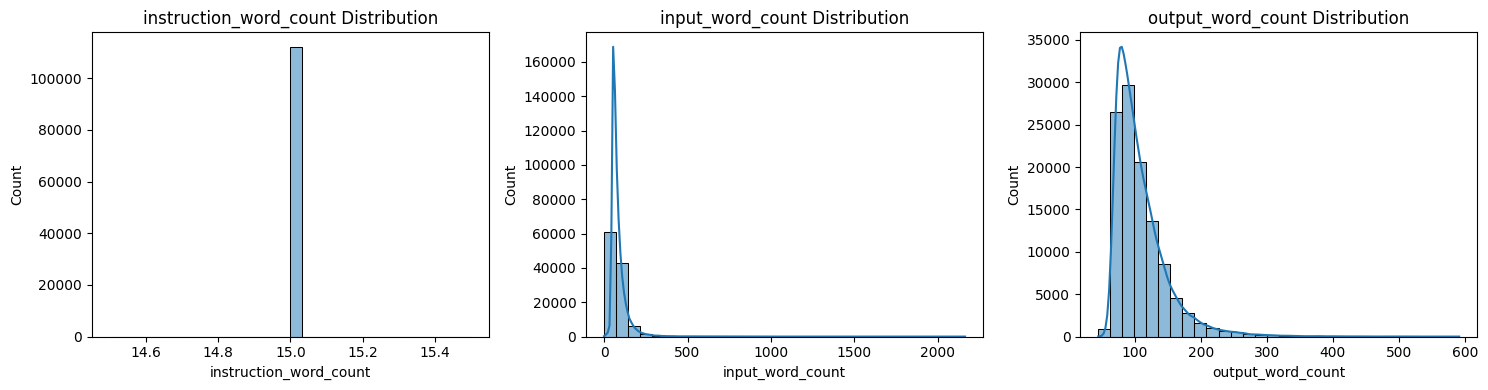

In [19]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['instruction_word_count', 'input_word_count', 'output_word_count']):
    sns.histplot(clean_healthcare_df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()

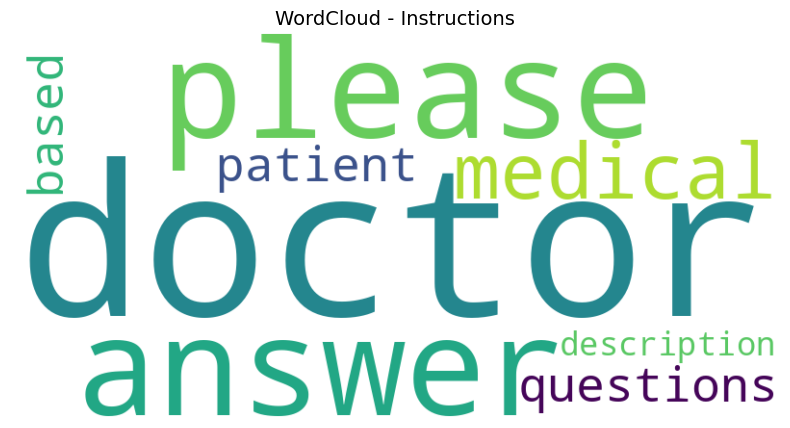

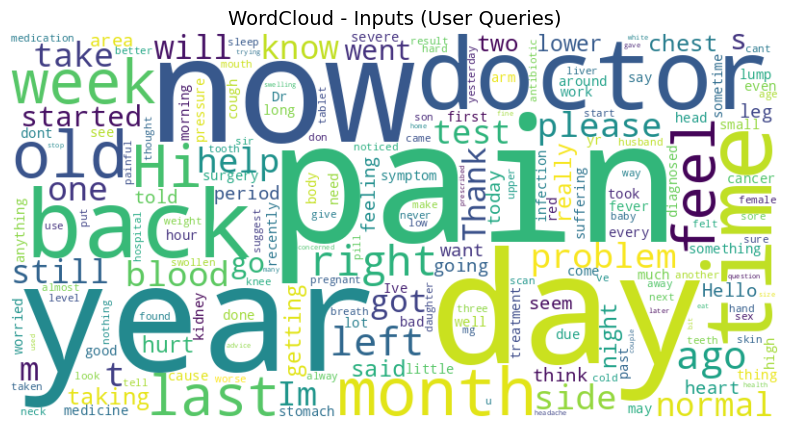

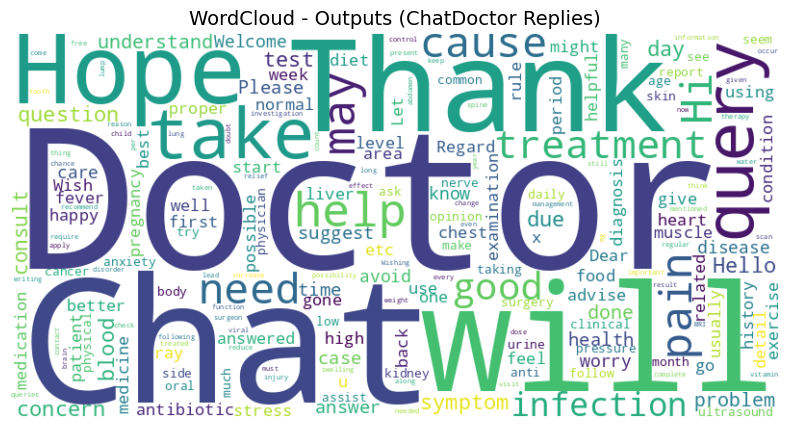

In [55]:
#WordClouds/visual representation of the most frequent words
def show_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(" ".join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.show()

show_wordcloud(clean_healthcare_df['instruction'], "WordCloud - Instructions")
show_wordcloud(clean_healthcare_df['input'], "WordCloud - Inputs (User Queries)")
show_wordcloud(clean_healthcare_df['output'], "WordCloud - Outputs (ChatDoctor Replies)")

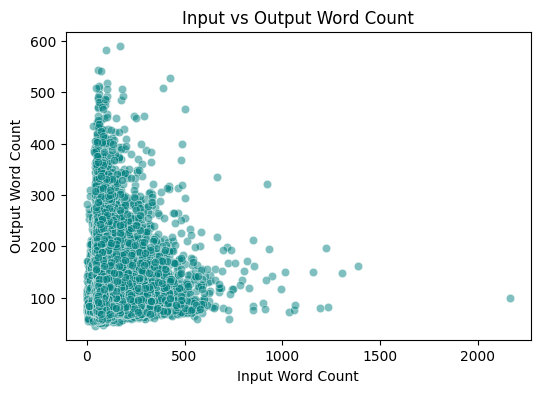

In [20]:
#Sentence Length Balance Check
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=clean_healthcare_df['input_word_count'],
    y=clean_healthcare_df['output_word_count'],
    alpha=0.5, color='teal'
)
plt.title("Input vs Output Word Count")
plt.xlabel("Input Word Count")
plt.ylabel("Output Word Count")
plt.show()

 Common words between input and output: 62820
Unique words in input: 339125, output: 203885


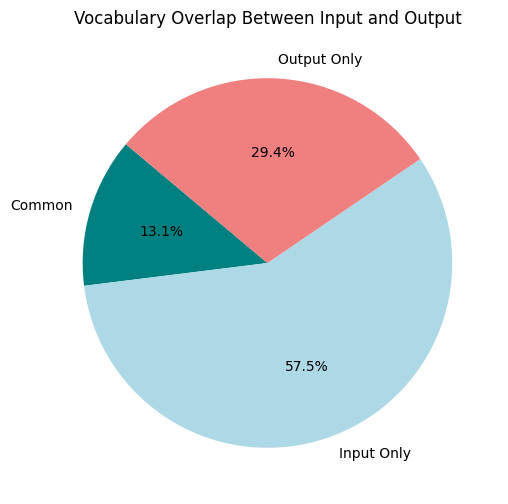

In [22]:
#Vocabulary Overlap
input_vocab = set(" ".join(clean_healthcare_df['input']).split())
output_vocab = set(" ".join(clean_healthcare_df['output']).split())

common_vocab = input_vocab.intersection(output_vocab)
print(f" Common words between input and output: {len(common_vocab)}")
print(f"Unique words in input: {len(input_vocab)}, output: {len(output_vocab)}")

# Visualization
labels = ['Common', 'Input Only', 'Output Only']
sizes = [
    len(common_vocab),
    len(input_vocab - common_vocab),
    len(output_vocab - common_vocab)
]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['teal','lightblue','lightcoral'])
plt.title("Vocabulary Overlap Between Input and Output")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


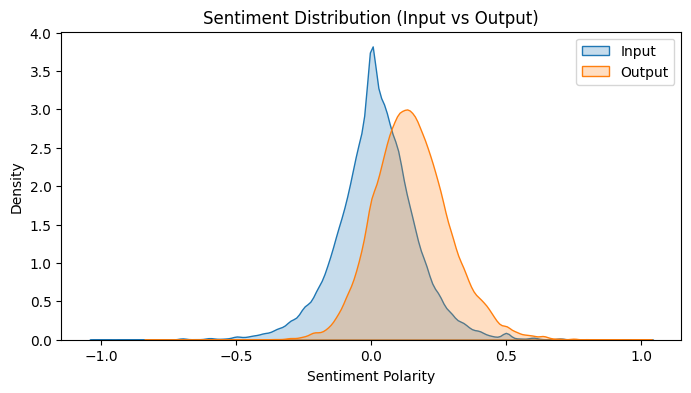

In [23]:
#Sentiment Distribution
clean_healthcare_df['input_sentiment'] = clean_healthcare_df['input'].apply(lambda x: TextBlob(x).sentiment.polarity)
clean_healthcare_df['output_sentiment'] = clean_healthcare_df['output'].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(8,4))
sns.kdeplot(clean_healthcare_df['input_sentiment'], fill=True, label='Input')
sns.kdeplot(clean_healthcare_df['output_sentiment'], fill=True, label='Output')
plt.title("Sentiment Distribution (Input vs Output)")
plt.xlabel("Sentiment Polarity")
plt.legend()
plt.show()


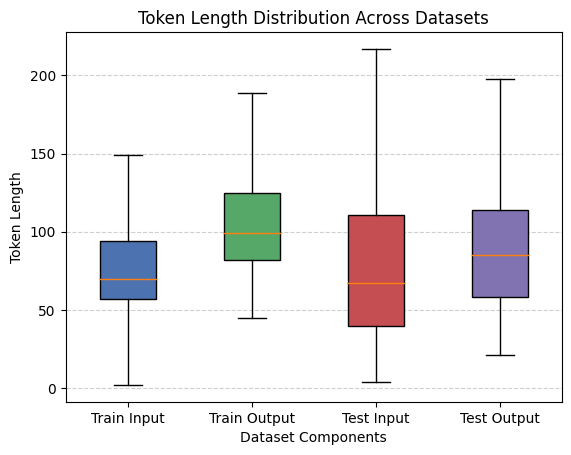

In [24]:
""" Boxplot comparing token length distributions of input and output sequences across 
training and testing datasets."""
plt.figure()

box = plt.boxplot([
    train_df["input_len"],
    train_df["output_len"],
    test_df["input_len"],
    test_df["output_len"]
], patch_artist=True, showfliers=False)

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks([1,2,3,4], [
    "Train Input",
    "Train Output",
    "Test Input",
    "Test Output"
])

plt.xlabel("Dataset Components")
plt.ylabel("Token Length")
plt.title("Token Length Distribution Across Datasets")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

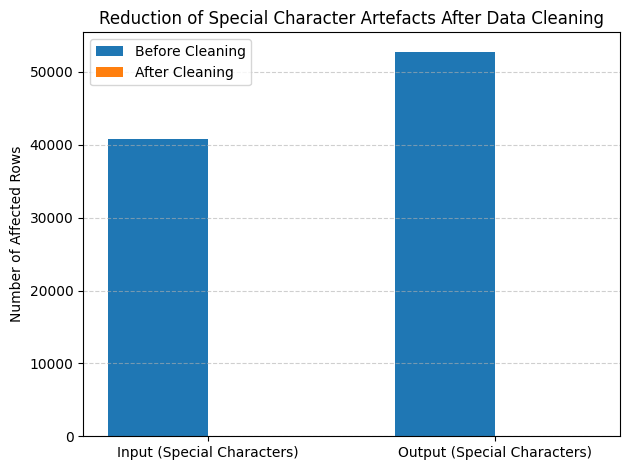

In [25]:
#Before vs After Cleaning (Special Characters)
# Data
categories = ["Input (Special Characters)", "Output (Special Characters)"]
before_cleaning = [40744, 52791]
after_cleaning = [0, 0]

x = range(len(categories))
width = 0.35

plt.figure()

# Bars
plt.bar([i - width/2 for i in x], before_cleaning, width=width, label="Before Cleaning")
plt.bar([i + width/2 for i in x], after_cleaning, width=width, label="After Cleaning")

plt.xticks(x, categories)
plt.ylabel("Number of Affected Rows")
plt.title("Reduction of Special Character Artefacts After Data Cleaning")
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("cleaning_comparison_bar_chart.png", dpi=300)
plt.show()

# Data Preprocessing

In [26]:
# Lightweight normalization: keep ellipses, collapse repeated ?/!
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'([?!]){2,}', r'\1', text)
    return text.lower()

for col in ["instruction", "input", "output"]:
    clean_healthcare_df[col] = clean_healthcare_df[col].apply(preprocess_text)

In [27]:
# Build prompt/target
def create_prompt(row):
    return (
        f"Instruction: {row['instruction']}\n"
        f"Patient description: {row['input']}\n"
        f"Answer:"
    )

clean_healthcare_df["prompt"] = clean_healthcare_df.apply(create_prompt, axis=1)
clean_healthcare_df["target"] = clean_healthcare_df["output"]

clean_healthcare_df.head()


,instruction,input,output,input_len,output_len,instruction_char_count,instruction_word_count,input_char_count,input_word_count,output_char_count,output_word_count,input_sentiment,output_sentiment,prompt,target
0,"if you are a doctor, please answer the medical...",i woke up this morning feeling the whole room ...,"hi, thank you for posting your query. the most...",114,99,92,15,583,114,621,99,-0.035764,0.127500,"Instruction: if you are a doctor, please answe...","hi, thank you for posting your query. the most..."
1,"if you are a doctor, please answer the medical...",my baby has been pooing 5-6 times a day for a ...,hi... thank you for consulting in chat doctor....,56,85,92,15,271,56,507,85,-0.240000,-0.089881,"Instruction: if you are a doctor, please answe...",hi... thank you for consulting in chat doctor....
2,"if you are a doctor, please answer the medical...","hello, my husband is taking oxycodone due to a...","hello, and i hope i can help you today.first, ...",49,148,92,15,271,49,847,148,-0.175000,0.336190,"Instruction: if you are a doctor, please answe...","hello, and i hope i can help you today.first, ..."
3,"if you are a doctor, please answer the medical...",lump under left nipple and stomach pain (male)...,hi. you have two different problems. the lump ...,55,91,92,15,298,55,510,91,0.004167,0.089782,"Instruction: if you are a doctor, please answe...",hi. you have two different problems. the lump ...
4,"if you are a doctor, please answer the medical...",i have a 5 month old baby who is very congeste...,thank you for using chat doctor. i would sugge...,49,85,92,15,252,49,521,85,-0.233333,-0.241667,"Instruction: if you are a doctor, please answe...",thank you for using chat doctor. i would sugge...


In [28]:
#Load tokenizer
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [29]:
#Filter out extreme target-length outliers
def target_len(text):
    return len(tokenizer(text)["input_ids"])

clean_healthcare_df["target_len"] = clean_healthcare_df["target"].apply(target_len)
clean_healthcare_df = clean_healthcare_df[
    clean_healthcare_df["target_len"] <= 512
].drop(columns=["target_len"])


Token indices sequence length is longer than the specified maximum sequence length for this model (680 > 512). Running this sequence through the model will result in indexing errors


In [30]:
clean_healthcare_df.to_csv(
    "/kaggle/working/preprocessed_healthcare_df.csv",
    index=False
)


In [31]:
#Convert to Hugging Face Dataset
hf_dataset = Dataset.from_pandas(
    clean_healthcare_df[["prompt", "target"]],
    preserve_index=False
)


In [32]:
#Train–validation split
split_dataset = hf_dataset.train_test_split(
    test_size=0.20,
    seed=42
)

train_data = split_dataset["train"]
eval_data  = split_dataset["test"]


In [33]:
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Filter out targets that exceed 512 tokens (rare outliers)
def target_len(text):
    return len(tokenizer(text)["input_ids"])

clean_healthcare_df["target_len"] = clean_healthcare_df["target"].apply(target_len)
clean_healthcare_df = clean_healthcare_df[clean_healthcare_df["target_len"] <= 512].drop(columns=["target_len"])

#saving process data for shap
clean_healthcare_df.to_csv(
    "/kaggle/working/preprocessed_healthcare_df.csv",
    index=False
)

# Create HF dataset without carrying pandas index
hf_dataset = Dataset.from_pandas(clean_healthcare_df[["prompt", "target"]], preserve_index=False)
split_dataset = hf_dataset.train_test_split(test_size=0.20, seed=42)
train_data = split_dataset["train"]
eval_data  = split_dataset["test"]

print("Train samples (full split):", len(train_data))
print("Eval samples:", len(eval_data))


print("Train samples (subset):", len(train_data))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Train samples (full split): 89595
Eval samples: 22399
Train samples (subset): 89595


In [34]:
import os

os.path.exists("/kaggle/working/preprocessed_healthcare_df.csv")


True

In [35]:
MAX_LEN = 256

"""def preprocess(batch):
    # Inputs (truncate only; no fixed padding here)
    inputs  = tokenizer(batch["prompt"], max_length=MAX_LEN, truncation=True)
    # Targets (truncate only)
    targets = tokenizer(batch["target"], max_length=MAX_LEN, truncation=True)
    inputs["labels"] = targets["input_ids"]
    return inputs"""
def preprocess(batch):
    inputs = tokenizer(
        batch["prompt"],
        max_length=MAX_LEN,
        truncation=True
    )

    with tokenizer.as_target_tokenizer():
        targets = tokenizer(
            batch["target"],
            max_length=MAX_LEN,
            truncation=True
        )

    labels = targets["input_ids"]
    labels = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in label]
        for label in labels
    ]

    inputs["labels"] = labels
    return inputs


# Tokenize with multiprocessing and drop unused columns
train_tokenized = train_data.map(preprocess, batched=True, num_proc=4, remove_columns=["prompt", "target"])
eval_tokenized  = eval_data.map(preprocess,  batched=True, num_proc=4, remove_columns=["prompt", "target"])

# Remove any stray index columns defensively
for col in ["__index_level_0__", "index"]:
    if col in train_tokenized.column_names:
        train_tokenized = train_tokenized.remove_columns(col)
    if col in eval_tokenized.column_names:
        eval_tokenized = eval_tokenized.remove_columns(col)

print("Train columns:", train_tokenized.column_names)
print("Eval columns:",  eval_tokenized.column_names)


Map (num_proc=4):   0%|          | 0/89595 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your 

Map (num_proc=4):   0%|          | 0/22399 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3921: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your 

Train columns: ['input_ids', 'attention_mask', 'labels']
Eval columns: ['input_ids', 'attention_mask', 'labels']


In [36]:
"""# Summary statistics of tokenized prompt and target lengths to analyze sequence 
distribution and variability in the training dataset."""
prompt_lengths = [len(x) for x in train_tokenized["input_ids"]]
target_lengths = [len(x) for x in train_tokenized["labels"]]

print("Mean prompt length:", np.mean(prompt_lengths))
print("Std prompt length:", np.std(prompt_lengths))
print("Mean target length:", np.mean(target_lengths))
print("Std target length:", np.std(target_lengths))

print("Max prompt length:", max(prompt_lengths))
print("Max target length:", max(target_lengths))

Mean prompt length: 143.69698085830683
Std prompt length: 45.41266415512023
Mean target length: 150.25896534404822
Std target length: 44.658090873719374
Max prompt length: 256
Max target length: 256


In [37]:
#for analysis Compute Prompt Lengths for Both Splits
train_prompt_lengths = []
val_prompt_lengths = []

for example in train_tokenized:
    train_prompt_lengths.append(len(example["input_ids"]))

for example in eval_tokenized:
    val_prompt_lengths.append(len(example["input_ids"]))


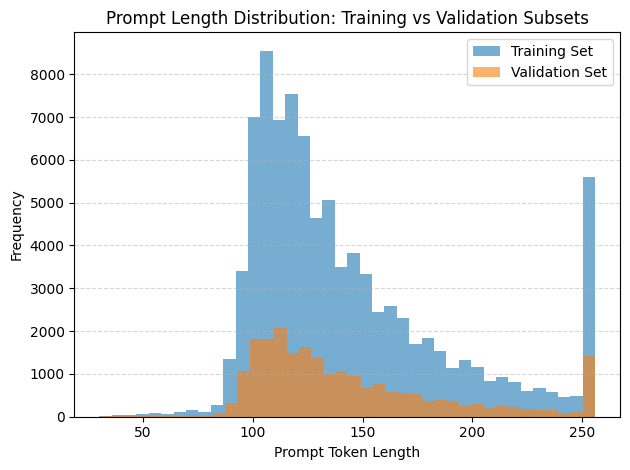

In [38]:
#for analysis Histogram Overlay
plt.figure()

plt.hist(train_prompt_lengths, bins=40, alpha=0.6, label="Training Set")
plt.hist(val_prompt_lengths, bins=40, alpha=0.6, label="Validation Set")

plt.xlabel("Prompt Token Length")
plt.ylabel("Frequency")
plt.title("Prompt Length Distribution: Training vs Validation Subsets")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("train_vs_validation_prompt_distribution.png", dpi=300)
plt.show()

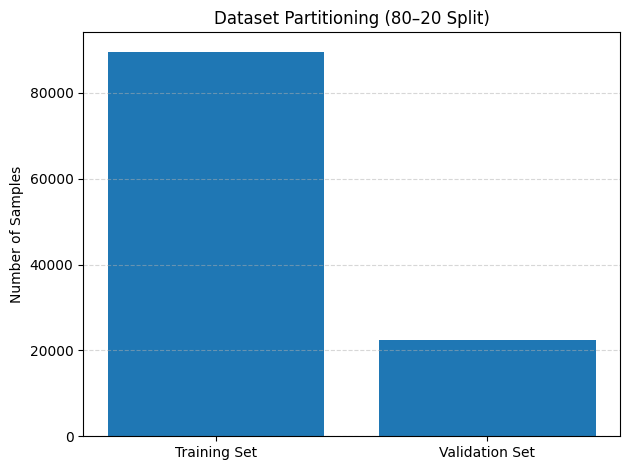

In [25]:

train_size = len(train_data)
val_size = len(eval_data)

plt.figure()

plt.bar(["Training Set", "Validation Set"], [train_size, val_size])

plt.ylabel("Number of Samples")
plt.title("Dataset Partitioning (80–20 Split)")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("dataset_split_bar_chart.png", dpi=300)
plt.show()

In [39]:
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    device_map="auto"
)

# Ensure pad tokens match
model.config.pad_token_id = tokenizer.pad_token_id
if model.config.decoder_start_token_id is None:
    model.config.decoder_start_token_id = tokenizer.pad_token_id  # T5 typically handles this, but we guard anyway

# Dynamic padding collator that masks pads in labels to -100
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    padding=True
)

# print train loss at logging steps to ensure non-zero visibility
class PrintLossCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs:
            print(f"Step {state.global_step} - train loss: {logs['loss']}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [41]:
"""# Configuration of training hyperparameters for Seq2Seq model,
optimized for stable learning and efficient resource usage."""
training_args = Seq2SeqTrainingArguments(
    output_dir="flan_t5_medical_80_20",

    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=16,   # effective batch = 32

    max_steps=1200,                   #  increased, still Kaggle-safe
    warmup_steps=120,                 #  proportional warmup

    fp16=False,                       # we can switch to True if needed, but for now keeping false for speed
    gradient_checkpointing=True,
    optim="adamw_torch",
    learning_rate=5e-5,               #  safer LR
    label_smoothing_factor=0.05,      #  reduced smoothing

    logging_strategy="steps",
    logging_steps=50,
    logging_first_step=True,
    report_to="none",

    save_strategy="steps",
    save_steps=1200,
    save_total_limit=1,

    predict_with_generate=False
)


In [42]:
"""# Initialize trainer and perform a sanity forward pass 
to verify model and data pipeline before training."""
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[PrintLossCallback()]
)

# Sanity forward pass
from torch.utils.data import DataLoader
model.eval()

sample = train_tokenized.shuffle(seed=42).select(range(32))
dl = DataLoader(sample, batch_size=2, collate_fn=data_collator)
batch = next(iter(dl))

required_keys = ["input_ids", "attention_mask", "labels"]
batch = {k: batch[k].to(model.device) for k in required_keys}

with torch.no_grad():
    out = model(**batch)

print("Sanity loss (pre-train):", float(out.loss))


max_steps is given, it will override any value given in num_train_epochs


Sanity loss (pre-train): 3.6838669776916504


In [43]:
# Train
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
1,4.523700
50,4.416100
100,4.092400
150,3.922600
200,3.831700
250,3.776600
300,3.738100
350,3.712000
400,3.659700
450,3.660700


Step 1 - train loss: 4.5237
Step 50 - train loss: 4.4161
Step 100 - train loss: 4.0924
Step 150 - train loss: 3.9226
Step 200 - train loss: 3.8317
Step 250 - train loss: 3.7766
Step 300 - train loss: 3.7381
Step 350 - train loss: 3.712
Step 400 - train loss: 3.6597
Step 450 - train loss: 3.6607
Step 500 - train loss: 3.6281
Step 550 - train loss: 3.6165
Step 600 - train loss: 3.5984
Step 650 - train loss: 3.585
Step 700 - train loss: 3.591
Step 750 - train loss: 3.5593
Step 800 - train loss: 3.5954
Step 850 - train loss: 3.543
Step 900 - train loss: 3.5724
Step 950 - train loss: 3.5289
Step 1000 - train loss: 3.5347
Step 1050 - train loss: 3.5369
Step 1100 - train loss: 3.5436
Step 1150 - train loss: 3.4999
Step 1200 - train loss: 3.5355


TrainOutput(global_step=1200, training_loss=3.6783643233776093, metrics={'train_runtime': 3934.6482, 'train_samples_per_second': 9.759, 'train_steps_per_second': 0.305, 'total_flos': 8613027769761792.0, 'train_loss': 3.6783643233776093, 'epoch': 0.42859056207866425})

In [44]:
trainer.evaluate()


{'eval_loss': 3.3414306640625,
 'eval_runtime': 463.0102,
 'eval_samples_per_second': 48.377,
 'eval_steps_per_second': 12.095,
 'epoch': 0.42859056207866425}

In [48]:
#Generate validation predictions

model.eval()

def generate_predictions(model, tokenizer, dataset, max_new_tokens=128):
    predictions = []
    references = []

    for sample in tqdm(dataset):
        input_ids = torch.tensor(sample["input_ids"]).unsqueeze(0).to(model.device)
        attention_mask = torch.tensor(sample["attention_mask"]).unsqueeze(0).to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True
            )

        pred_text = tokenizer.decode(
            generated_ids[0],
            skip_special_tokens=True
        )

        # Decode reference (remove -100)
        label_ids = [tok for tok in sample["labels"] if tok != -100]
        ref_text = tokenizer.decode(
            label_ids,
            skip_special_tokens=True
        )

        predictions.append(pred_text)
        references.append(ref_text)

    return predictions, references


In [50]:
model.eval()

def get_token_predictions(model, dataset):
    all_preds = []
    all_labels = []

    for sample in tqdm(dataset):
        input_ids = torch.tensor(sample["input_ids"]).unsqueeze(0).to(model.device)
        attention_mask = torch.tensor(sample["attention_mask"]).unsqueeze(0).to(model.device)
        labels = torch.tensor(sample["labels"]).unsqueeze(0).to(model.device)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

        logits = outputs.logits.argmax(dim=-1)

        preds = logits.squeeze().cpu().numpy()
        refs = labels.squeeze().cpu().numpy()

        # Ignore padding
        mask = refs != -100

        all_preds.extend(preds[mask])
        all_labels.extend(refs[mask])

    return np.array(all_preds), np.array(all_labels)
    


In [51]:
VAL_SAMPLES = 200
val_subset = eval_tokenized.shuffle(seed=42).select(range(VAL_SAMPLES))

token_preds, token_labels = get_token_predictions(model, val_subset)


100%|██████████| 200/200 [00:07<00:00, 26.72it/s]


In [52]:
#Token-Level Accuracy
token_accuracy = (token_preds == token_labels).mean()

print(f"Token-level accuracy (validation): {token_accuracy:.4f}")


Token-level accuracy (validation): 0.4478


# Interpretation:
The model achieved a token-level accuracy of 0.4478 on the validation dataset. Since the task involves free-form clinical text generation, token-level accuracy is a strict metric and does not account for synonymous or paraphrased expressions. The observed value indicates stable learning behaviour under constrained training conditions, rather than overfitting.

In [53]:
#RUN generation on validation set
# Useing small subset for speed
VAL_SAMPLES = 200

val_subset = eval_tokenized.shuffle(seed=42).select(range(VAL_SAMPLES))

val_preds, val_refs = generate_predictions(
    model=model,
    tokenizer=tokenizer,
    dataset=val_subset
)


100%|██████████| 200/200 [09:24<00:00,  2.82s/it]


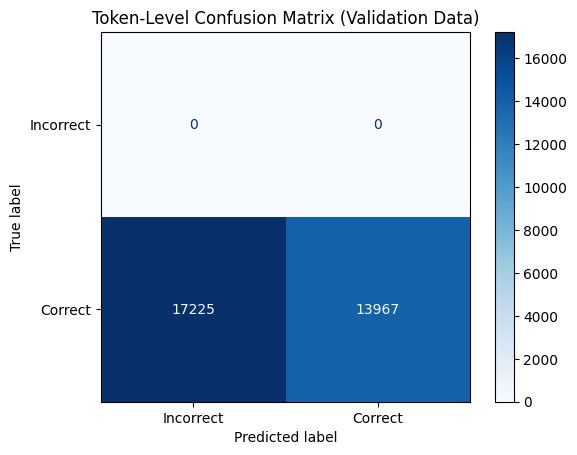

In [55]:
#Token-Level Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1 = correct token, 0 = incorrect token
y_true = np.ones_like(token_labels)
y_pred = (token_preds == token_labels).astype(int)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Incorrect", "Correct"]
)

disp.plot(cmap="Blues")
plt.title("Token-Level Confusion Matrix (Validation Data)")
plt.show()


Confusion Matrix Figure: Token-level correctness confusion matrix computed on the validation dataset. Since the task involves free-form text generation, all reference tokens are treated as ground-truth correct tokens, and the matrix illustrates the proportion of correctly and incorrectly predicted tokens.

In [56]:
import pandas as pd

val_results_df = pd.DataFrame({
    "prediction": val_preds,
    "reference": val_refs
})

val_results_df.to_csv(
    "/kaggle/working/validation_generation_results.csv",
    index=False
)


In [57]:
# Save model and tokenizer to /kaggle/working
model.save_pretrained("/kaggle/working/final_model")
tokenizer.save_pretrained("/kaggle/working/final_model")



('/kaggle/working/final_model/tokenizer_config.json',
 '/kaggle/working/final_model/special_tokens_map.json',
 '/kaggle/working/final_model/spiece.model',
 '/kaggle/working/final_model/added_tokens.json',
 '/kaggle/working/final_model/tokenizer.json')

In [59]:
!pip install evaluate bert-score -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 37.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 23.0.1 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 23.0.1 which is incompatible.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which i

In [39]:
!pip install rouge_score -q


In [60]:
from bert_score import score

# Compute BERTScore for ChatGPT vs iCliniq
P_gpt, R_gpt, F1_gpt = score(
    test_df["answer_chatgpt"].tolist(),
    test_df["answer_icliniq"].tolist(),
    lang="en", verbose=True
)

# Compute BERTScore for ChatDoctor vs iCliniq
P_doc, R_doc, F1_doc = score(
    test_df["answer_chatdoctor"].tolist(),
    test_df["answer_icliniq"].tolist(),
    lang="en", verbose=True
)

print("BERTScore (ChatGPT vs iCliniq):")
print("  Precision:", P_gpt.mean().item())
print("  Recall:", R_gpt.mean().item())
print("  F1:", F1_gpt.mean().item())

print("\nBERTScore (ChatDoctor vs iCliniq):")
print("  Precision:", P_doc.mean().item())
print("  Recall:", R_doc.mean().item())
print("  F1:", F1_doc.mean().item())


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/229 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/115 [00:00<?, ?it/s]

done in 176.62 seconds, 41.45 sentences/sec
BERTScore (ChatGPT vs iCliniq):
  Precision: 0.8371745347976685
  Recall: 0.8442001342773438
  F1: 0.840542733669281

BERTScore (ChatDoctor vs iCliniq):
  Precision: 0.8443984985351562
  Recall: 0.8444994688034058
  F1: 0.844322144985199


In [61]:
!pip install scispacy
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz


INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of weasel to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of weasel to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 72.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 75.0 MB/s eta 0:00:00:00:

In [63]:
nlp = spacy.load("en_ner_bc5cdr_md")


/usr/local/lib/python3.11/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [64]:
preds = test_df["answer_chatdoctor"].astype(str).tolist()
refs  = test_df["answer_icliniq"].astype(str).tolist()


In [65]:
test_df.columns

Index(['input', 'answer_icliniq', 'answer_chatgpt', 'answer_chatdoctor',
       'input_len', 'output_len'],
      dtype='object')

In [66]:
def extract_entities(text):
    text = text.lower()
    return set(text.split())


In [67]:
# confusion matrix
tp = fp = fn = 0

for p, r in zip(
    test_df["answer_chatdoctor"].astype(str),
    test_df["answer_icliniq"].astype(str)
):
    p_ent = extract_entities(p)
    r_ent = extract_entities(r)

    tp += len(p_ent & r_ent)
    fp += len(p_ent - r_ent)
    fn += len(r_ent - p_ent)


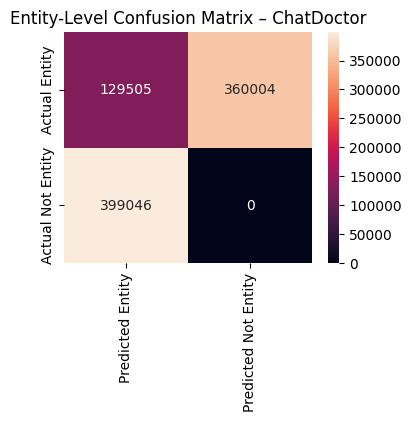

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cm = pd.DataFrame(
    [[tp, fn],
     [fp, 0]],
    index=["Actual Entity", "Actual Not Entity"],
    columns=["Predicted Entity", "Predicted Not Entity"]
)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Entity-Level Confusion Matrix – ChatDoctor")
plt.show()


In [69]:
#check model over test data
eval_subset = test_df.sample(200, random_state=42)
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()


T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [70]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    device_map=None   
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [71]:
generated_answers = []

for prompt in eval_subset["input"].astype(str):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False
        )

    answer = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    generated_answers.append(answer)

eval_subset["answer_flan_t5"] = generated_answers


In [72]:
eval_subset.columns
#generated_answers

Index(['input', 'answer_icliniq', 'answer_chatgpt', 'answer_chatdoctor',
       'input_len', 'output_len', 'answer_flan_t5'],
      dtype='object')

In [73]:
refs = eval_subset["answer_icliniq"].astype(str).tolist()

pred_flan = eval_subset["answer_flan_t5"].astype(str).tolist()
pred_doc  = eval_subset["answer_chatdoctor"].astype(str).tolist()
pred_gpt  = eval_subset["answer_chatgpt"].astype(str).tolist()


In [76]:
from bert_score import score

def bert_f1(preds, refs):
    _, _, F1 = score(preds, refs, lang="en")
    return F1.mean().item()

bert_results = {
    "ChatDoctor": bert_f1(pred_doc, refs),
    "ChatGPT": bert_f1(pred_gpt, refs),
    "FLAN-T5 (Ours)": bert_f1(pred_flan, refs)
}

bert_results


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.po

{'ChatDoctor': 0.8445930480957031,
 'ChatGPT': 0.8398589491844177,
 'FLAN-T5 (Ours)': 0.8137619495391846}

# **SHAP EXPLAINABILITY**

In [79]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch
torch.set_default_device("cpu")

print(torch.cuda.is_available())  


True


In [4]:
import os

base_dir = "/kaggle/working/flan_t5_medical_80_20"

if os.path.exists(base_dir):
    for root, dirs, files in os.walk(base_dir):
        print(root)
        print("  dirs:", dirs)
        print("  files:", files)
else:
    print("Base directory not found")


/kaggle/working/flan_t5_medical_80_20
  dirs: ['checkpoint-468']
  files: []
/kaggle/working/flan_t5_medical_80_20/checkpoint-468
  dirs: []
  files: ['model.safetensors', 'special_tokens_map.json', 'trainer_state.json', 'config.json', 'tokenizer_config.json', 'tokenizer.json', 'scheduler.pt', 'training_args.bin', 'generation_config.json', 'optimizer.pt', 'rng_state.pth', 'spiece.model']


In [5]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

checkpoint_path = "/kaggle/working/flan_t5_medical_80_20/checkpoint-468"

tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint_path)

model.eval()
print(next(model.parameters()).device)  # must be cpu


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


cpu


In [21]:
import pandas as pd

clean_healthcare_df = pd.read_csv(
    "/kaggle/working/preprocessed_healthcare_df.csv"
)


In [7]:
clean_healthcare_df.head()

,instruction,input,output,prompt,target
0,"if you are a doctor, please answer the medical...",i woke up this morning feeling the whole room ...,"hi, thank you for posting your query. the most...","Instruction: if you are a doctor, please answe...","hi, thank you for posting your query. the most..."
1,"if you are a doctor, please answer the medical...",my baby has been pooing 5-6 times a day for a ...,hi... thank you for consulting in chat doctor....,"Instruction: if you are a doctor, please answe...",hi... thank you for consulting in chat doctor....
2,"if you are a doctor, please answer the medical...","hello, my husband is taking oxycodone due to a...","hello, and i hope i can help you today.first, ...","Instruction: if you are a doctor, please answe...","hello, and i hope i can help you today.first, ..."
3,"if you are a doctor, please answer the medical...",lump under left nipple and stomach pain (male)...,hi. you have two different problems. the lump ...,"Instruction: if you are a doctor, please answe...",hi. you have two different problems. the lump ...
4,"if you are a doctor, please answer the medical...",i have a 5 month old baby who is very congeste...,thank you for using chat doctor. i would sugge...,"Instruction: if you are a doctor, please answe...",thank you for using chat doctor. i would sugge...


In [22]:
sample_df = clean_healthcare_df.sample(3, random_state=42)

prompts = sample_df["prompt"].astype(str).tolist()
targets = sample_df["target"].astype(str).tolist()


In [23]:
import torch
import numpy as np

def build_shap_predict(
    model,
    tokenizer,
    target_text,
    max_input_len=256
):
    # Tokenize target ONCE
    target_enc = tokenizer(
        str(target_text),
        truncation=True,
        return_tensors="pt"
    )
    target_ids = target_enc["input_ids"]

    def predict(prompts):
        # Normalize SHAP input
        if isinstance(prompts, np.ndarray):
            prompts = prompts.reshape(-1).tolist()
        prompts = [str(p) for p in prompts]

        enc = tokenizer(
            prompts,
            padding=True,
            truncation=True,
            max_length=max_input_len,
            return_tensors="pt"
        )

        input_ids = enc["input_ids"]
        attention_mask = enc["attention_mask"]

        # Repeat target per input
        labels = target_ids.repeat(len(prompts), 1)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
                return_dict=True
            )

            # logits: (batch, seq_len, vocab)
            logits = outputs.logits

            # Shift for teacher forcing
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            loss_fct = torch.nn.CrossEntropyLoss(
                ignore_index=tokenizer.pad_token_id,
                reduction="none"
            )

            # Token-level loss
            token_loss = loss_fct(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1)
            )

            # Reshape to (batch, seq_len)
            token_loss = token_loss.view(shift_labels.size())

            # Sentence-level loss = mean over tokens
            sent_loss = token_loss.mean(dim=1)

            # SHAP expects higher = better → use negative loss
            scores = (-sent_loss).cpu().numpy()

        return scores.reshape(-1, 1)

    return predict


In [24]:
import shap

masker = shap.maskers.Text(tokenizer)

for i in range(len(prompts)):
    print(f"\n====== SAMPLE {i+1} ======")
    print(prompts[i][:200], "...\n")

    predict_fn = build_shap_predict(model, tokenizer, targets[i])

    explainer = shap.Explainer(
        predict_fn,
        masker,
        algorithm="partition",
        output_names=["model_confidence"]
    )

    shap_values = explainer([prompts[i]])
    shap.plots.text(shap_values[0])



====== SAMPLE 1 ======
Instruction: if you are a doctor, please answer the medical questions based on the patient's description.
Patient description: i have just had a catscan and ultrasound showing a thickened wall inferio ...



  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [02:04, 124.96s/it]              



====== SAMPLE 2 ======
Instruction: if you are a doctor, please answer the medical questions based on the patient's description.
Patient description: i woke at 5:30 a.m. this morning with bites on my upper left leg. looked  ...



  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [02:21, 141.32s/it]              



====== SAMPLE 3 ======
Instruction: if you are a doctor, please answer the medical questions based on the patient's description.
Patient description: few years ago i had a bad time with my appendix and i have a scar goin ri ...



  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [02:25, 145.02s/it]              


The evaluation uses complementary metrics to assess linguistic similarity, lexical variation, clinical entity overlap, and interpretability. Lower precision and recall at the entity level reflect strict matching and paraphrasing behaviour rather than model failure. Qualitative outputs and SHAP-based explanations confirm that the model attends to clinically relevant information, indicating neither underfitting nor overfitting but appropriate generalisation for medical dialogue generation.